In [2]:
pip install pandas psycopg2 sqlalchemy matplotlib seaborn


  Preparing metadata (setup.py) ... done
  Created wheel for psycopg2: filename=psycopg2-2.9.10-cp312-cp312-macosx_10_15_x86_64.whl size=135264 sha256=07dbdd56a67ea4dfbf1a8f25441d59d9841a81d252c17078206e4b92d0a7f975
  Stored in directory: /Users/apple/Library/Caches/pip/wheels/ac/bb/ce/afa589c50b6004d3a06fc691e71bd09c9bd5f01e5921e5329b
Successfully built psycopg2
Note: you may need to restart the kernel to use updated packages.


In [9]:
from sqlalchemy import create_engine
import pandas as pd
username = "postgres"                  
password = "gayu2202*"       
host = "localhost"                     
port = "5432" 
database = "sql_project_p1"
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")


In [11]:
df = pd.read_sql("SELECT * FROM retail_sales LIMIT 5", engine)
print(df.head())

   transaction_id   sale_date sale_time  customer_id  gender  age  category  \
0             180  2022-11-05  10:47:00          117    Male   41  Clothing   
1             522  2022-07-09  11:00:00           52    Male   46    Beauty   
2             559  2022-12-12  10:48:00            5  Female   40  Clothing   
3            1180  2022-01-06  08:53:00           85    Male   41  Clothing   
4            1522  2022-11-14  08:35:00           48    Male   46    Beauty   

   quantity  price_per_unit   cogs  total_sale  
0         3           300.0  129.0       900.0  
1         3           500.0  145.0      1500.0  
2         4           300.0   84.0      1200.0  
3         3           300.0  129.0       900.0  
4         3           500.0  235.0      1500.0  


In [13]:
query = """
SELECT 
  SUM("total_sale") AS total_sales,
  SUM("total_sale" - "cogs") AS total_profit
FROM retail_sales;
"""
df_total = pd.read_sql(query, engine)
print(df_total)


   total_sales  total_profit
0     911720.0      721957.3


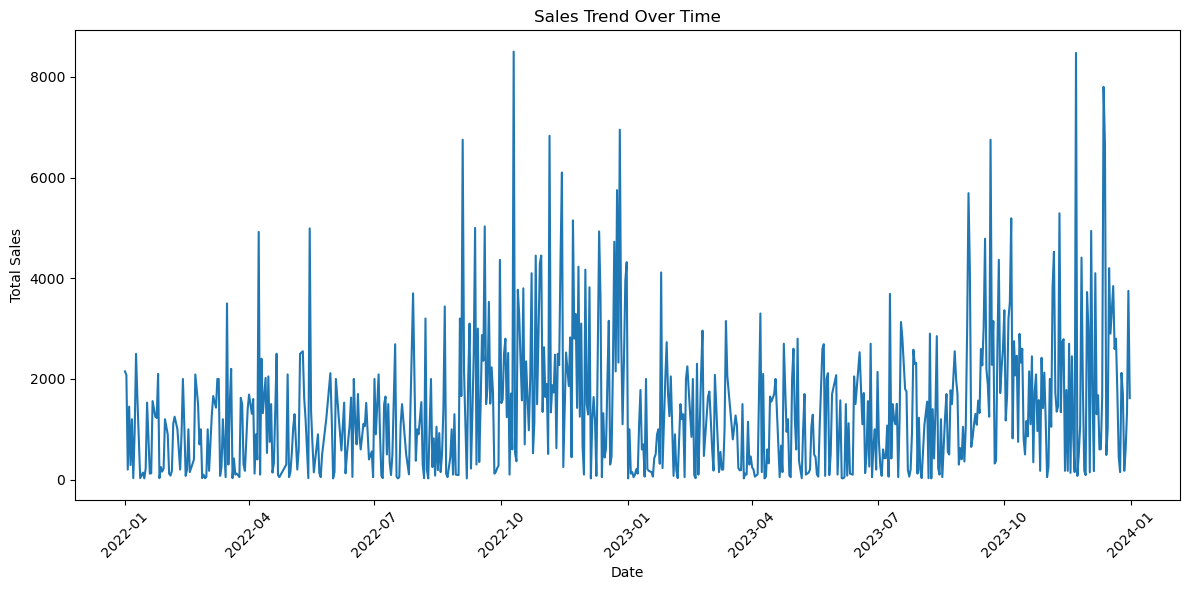

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
query = """
SELECT "sale_date", SUM("total_sale") AS total_sales
FROM retail_sales
GROUP BY "sale_date"
ORDER BY "sale_date";
"""
df_trend = pd.read_sql(query, engine)
df_trend["sale_date"] = pd.to_datetime(df_trend["sale_date"])

plt.figure(figsize=(12,6))
sns.lineplot(data=df_trend, x="sale_date", y="total_sales")
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


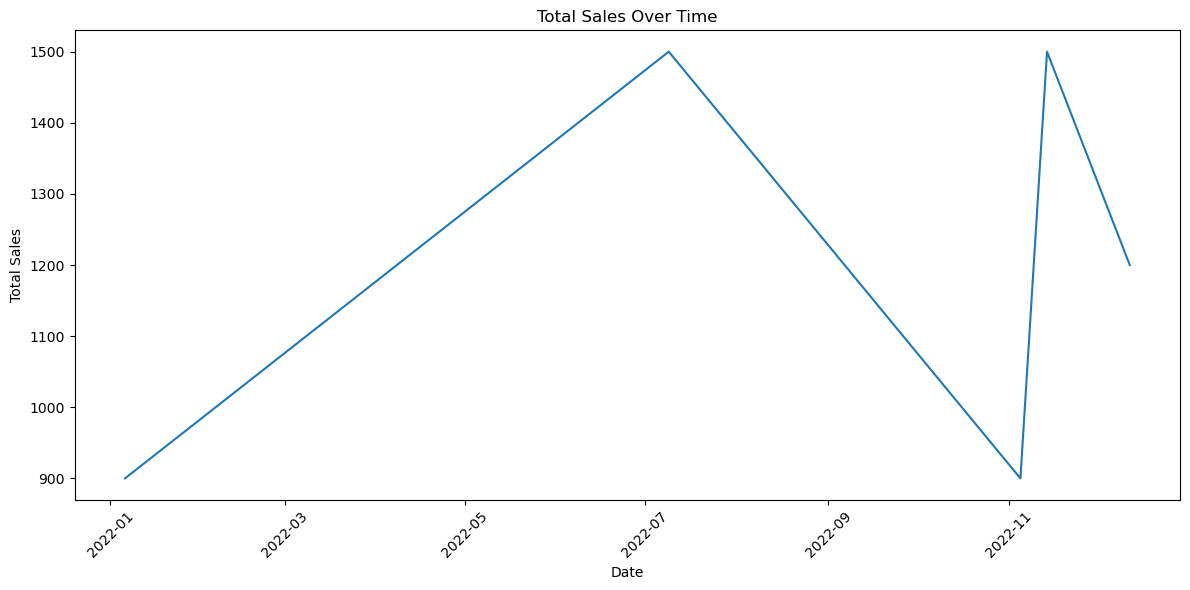

In [19]:
#Total sales over time
df['sale_date'] = pd.to_datetime(df['sale_date'])

daily_sales = df.groupby('sale_date')['total_sale'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='sale_date', y='total_sale', data=daily_sales)
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


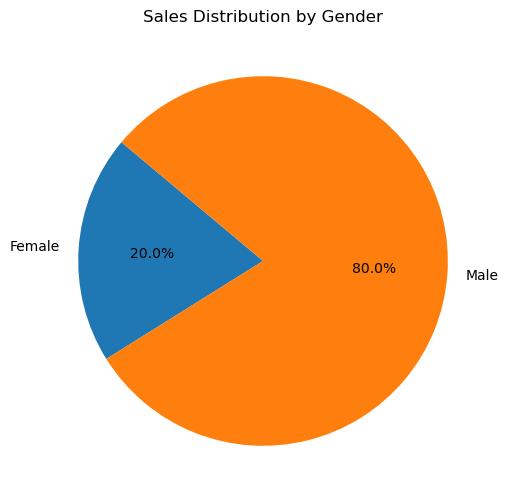

In [21]:
#Gender wise sales distribution
gender_sales = df.groupby('gender')['total_sale'].sum().reset_index()

plt.figure(figsize=(6,6))
plt.pie(gender_sales['total_sale'], labels=gender_sales['gender'], autopct='%1.1f%%', startangle=140)
plt.title('Sales Distribution by Gender')
plt.show()


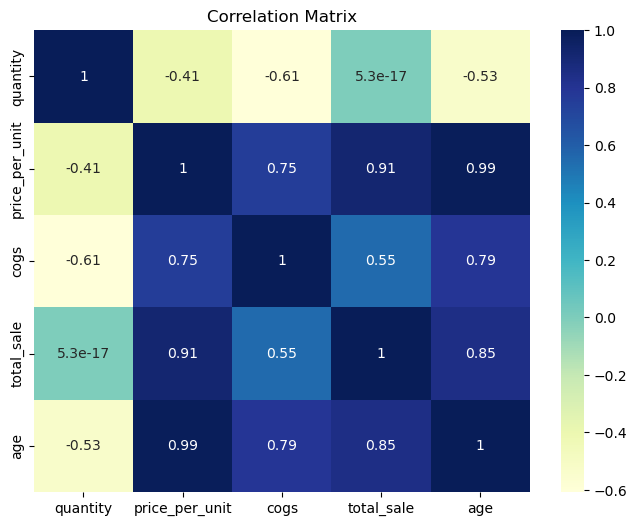

In [23]:
#Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['quantity', 'price_per_unit', 'cogs', 'total_sale', 'age']].corr(), annot=True, cmap='YlGnBu')
plt.title("Correlation Matrix")
plt.show()


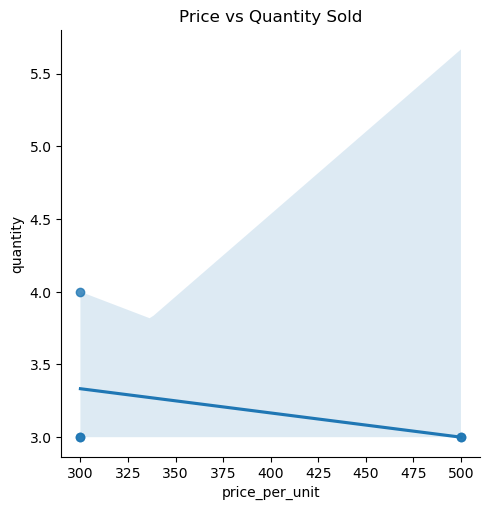

In [25]:
#Price vs Quantity scatter plot
sns.lmplot(x='price_per_unit', y='quantity', data=df)
plt.title("Price vs Quantity Sold")
plt.show()


/var/folders/2l/gwmldcgd4ksgs5cl7p72vc4r0000gn/T/ipykernel_9215/3593371015.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='total_sale', y='category', data=top_categories, palette='coolwarm')


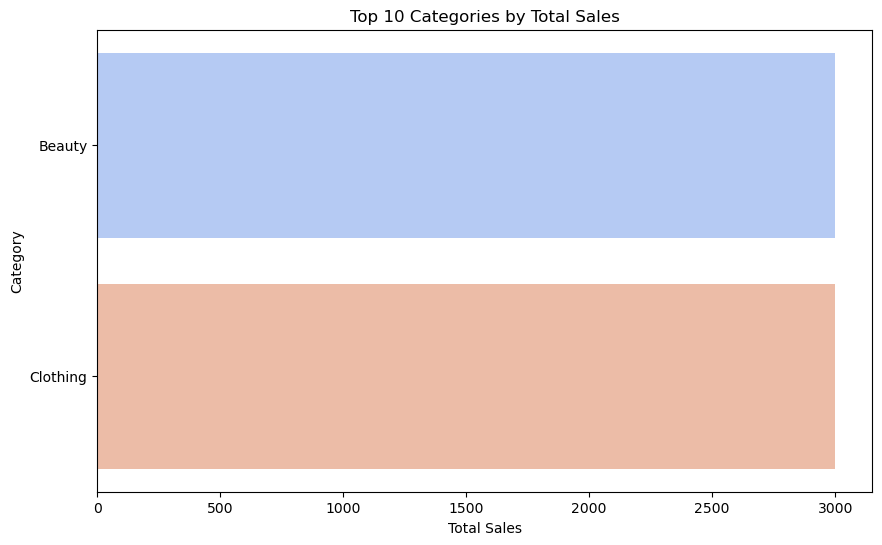

In [27]:
#Top 10 selling categories
top_categories = df.groupby('category')['total_sale'].sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(x='total_sale', y='category', data=top_categories, palette='coolwarm')
plt.title("Top 10 Categories by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.show()
